<a href="https://colab.research.google.com/github/springboardmentor1210a/Supportlytics/blob/VenkataLakshmi/Module_5%2C6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MODULE-5

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("cleaned_customer_support_tickets.csv")

priority
Urgent     120.162998
Low        120.280831
Medium     120.380844
High       121.626450
Unknown           NaN
Name: Resolution_Duration, dtype: float64


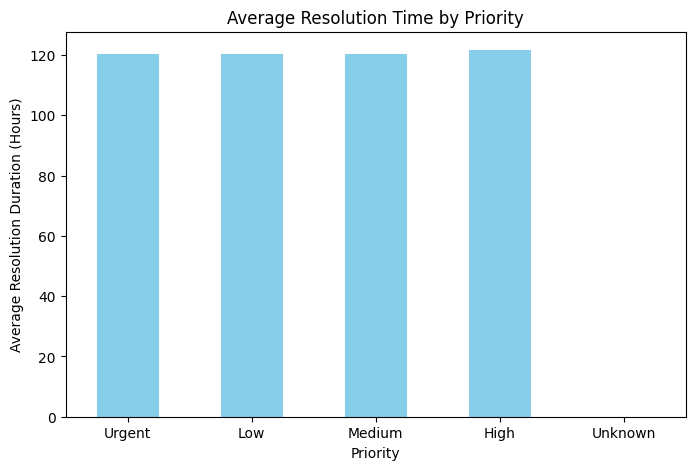

In [ ]:
priority_resolution = df.groupby('priority')['Resolution_Duration'].mean().sort_values()

print(priority_resolution)

plt.figure(figsize=(8,5))
priority_resolution.plot(kind='bar', color='skyblue')

plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Average Resolution Duration (Hours)")
plt.xticks(rotation=0)

plt.show()

category
Bug Report                   116.666809
Security Concern             118.892582
Account Suspension           119.878802
Payment Problem              119.919281
Performance Issue            121.359293
Feature Request              121.435142
Data Sync Issue              121.470744
Refund Request               121.575801
Subscription Cancellation    122.173871
Login Issue                  122.706516
Name: Resolution_Duration, dtype: float64


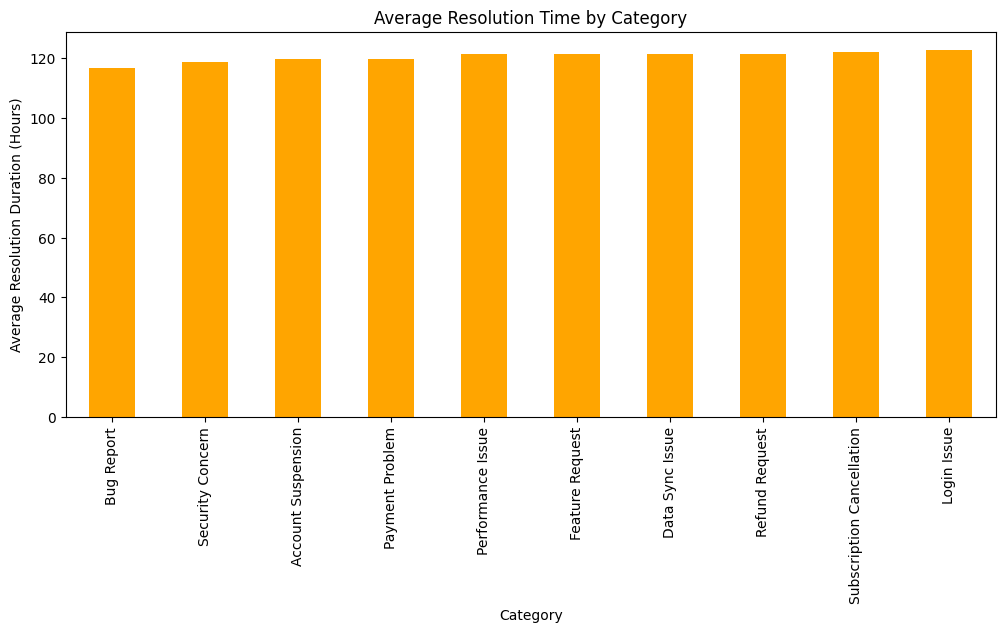

In [ ]:
category_resolution = df.groupby('category')['Resolution_Duration'].mean().sort_values()

print(category_resolution)

plt.figure(figsize=(12,5))
category_resolution.plot(kind='bar', color='orange')

plt.title("Average Resolution Time by Category")
plt.xlabel("Category")
plt.ylabel("Average Resolution Duration (Hours)")
plt.xticks(rotation=90)

plt.show()

region
North America    117.190960
South America    119.162864
Australia        121.153351
Asia             121.220053
Africa           122.434849
Europe           122.598048
Unknown                 NaN
Name: Resolution_Duration, dtype: float64


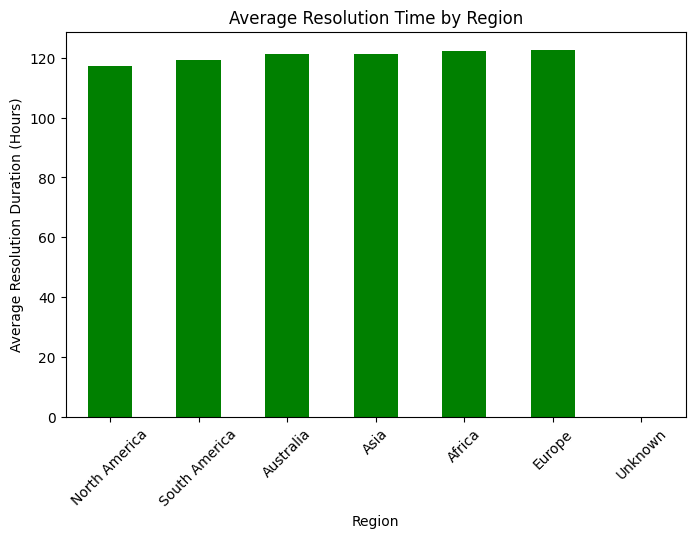

In [ ]:
region_resolution = df.groupby('region')['Resolution_Duration'].mean().sort_values()

print(region_resolution)

plt.figure(figsize=(8,5))
region_resolution.plot(kind='bar', color='green')

plt.title("Average Resolution Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Resolution Duration (Hours)")
plt.xticks(rotation=45)

plt.show()

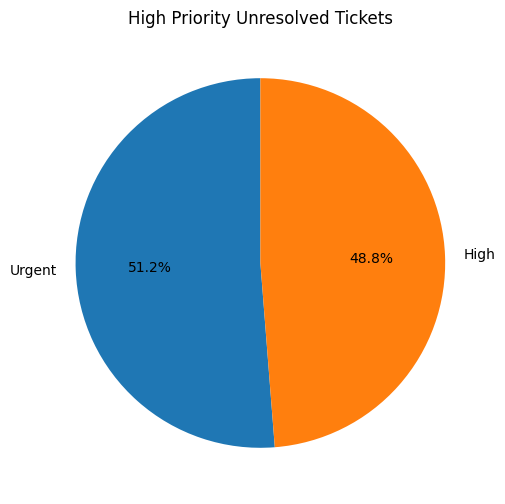

In [ ]:
import matplotlib.pyplot as plt

high_priority = df[
    (df['priority'].isin(['High', 'Urgent'])) &
    (df['status'] != 'Resolved')
]

counts = high_priority['priority'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("High Priority Unresolved Tickets")

plt.show()

priority
Urgent    2347
High      2233
Name: count, dtype: int64


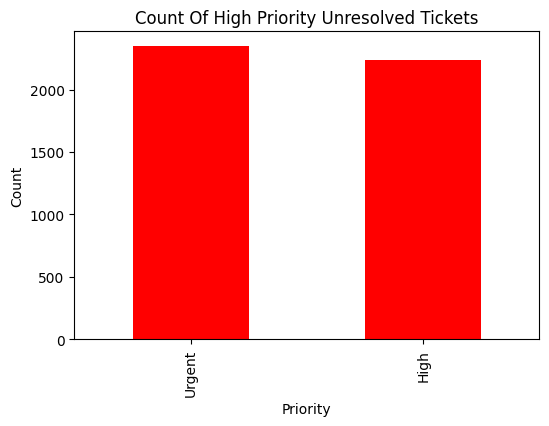

In [ ]:
counts = high_priority['priority'].value_counts()

print(counts)

plt.figure(figsize=(6,4))
counts.plot(kind='bar', color='red')

plt.title("Count Of High Priority Unresolved Tickets")
plt.xlabel("Priority")
plt.ylabel("Count")

plt.show()

In [ ]:
high_priority.to_csv("High_Priority_Unresolved_Tickets.csv", index=False)

MODULE-6

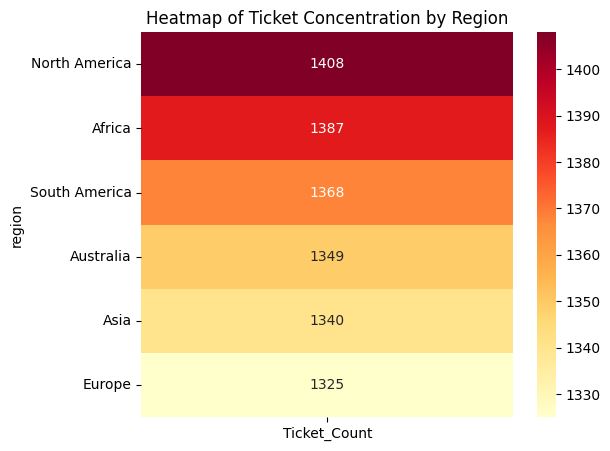

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

region_counts = df['region'].value_counts().to_frame(name='Ticket_Count')

plt.figure(figsize=(6,5))
sns.heatmap(region_counts,
            annot=True,
            cmap='YlOrRd',
            fmt='d')

plt.title("Heatmap of Ticket Concentration by Region")
plt.show()

In [ ]:
region_coordinates = {
    "North America": (54.5260, -105.2551),
    "South America": (-8.7832, -55.4915),
    "Europe": (54.5260, 15.2551),
    "Asia": (34.0479, 100.6197),
    "Africa": (8.7832, 34.5085),
    "Oceania": (-22.7359, 140.0188)
}

In [ ]:
df['region'] = df['region'].replace('Australia', 'Oceania')
df = df[df['region'] != 'Unknown']
df.dropna(subset=['region'], inplace=True)
df["Latitude"] = df["region"].map(lambda x: region_coordinates[x][0])
df["Longitude"] = df["region"].map(lambda x: region_coordinates[x][1])

In [ ]:
import pandas as pd
import plotly.express as px
df = pd.read_csv("cleaned_customer_support_tickets.csv")

region_coordinates = {
    "North America": (54.5260, -105.2551),
    "South America": (-8.7832, -55.4915),
    "Europe": (54.5260, 15.2551),
    "Asia": (34.0479, 100.6197),
    "Africa": (8.7832, 34.5085),
    "Oceania": (-22.7359, 140.0188)
}

df['region'] = df['region'].replace('Australia', 'Oceania')
df = df[df['region'] != 'Unknown']
df.dropna(subset=['region'], inplace=True)
df["Latitude"] = df["region"].map(lambda x: region_coordinates[x][0])
df["Longitude"] = df["region"].map(lambda x: region_coordinates[x][1])

fig = px.scatter_geo(
    df,
    lat="Latitude",
    lon="Longitude",
    color="category",
    hover_name="region",
    title="Issue Categories by Region"
)

fig.show()

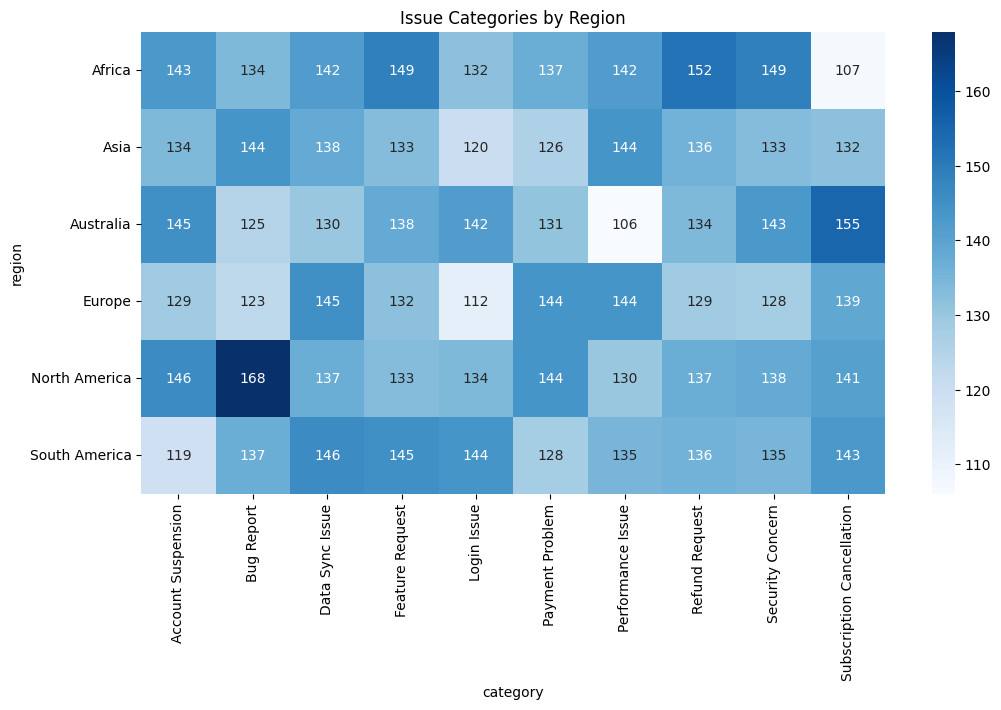

In [ ]:
pivot = pd.crosstab(df['region'], df['category'])

plt.figure(figsize=(12,6))
sns.heatmap(pivot,
            cmap='Blues',
            annot=True,
            fmt='d')

plt.title("Issue Categories by Region")
plt.show()

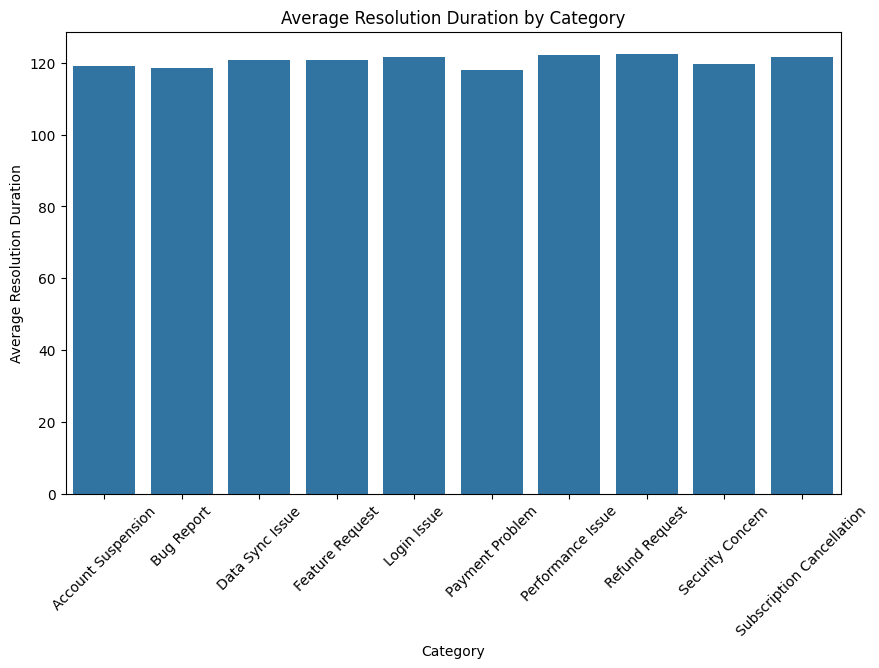

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

category_perf = (
    df.groupby('category')['Resolution_Duration']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=category_perf,
    x='category',
    y='Resolution_Duration'
)

plt.xticks(rotation=45)
plt.title("Average Resolution Duration by Category")
plt.xlabel("Category")
plt.ylabel("Average Resolution Duration")

plt.show()

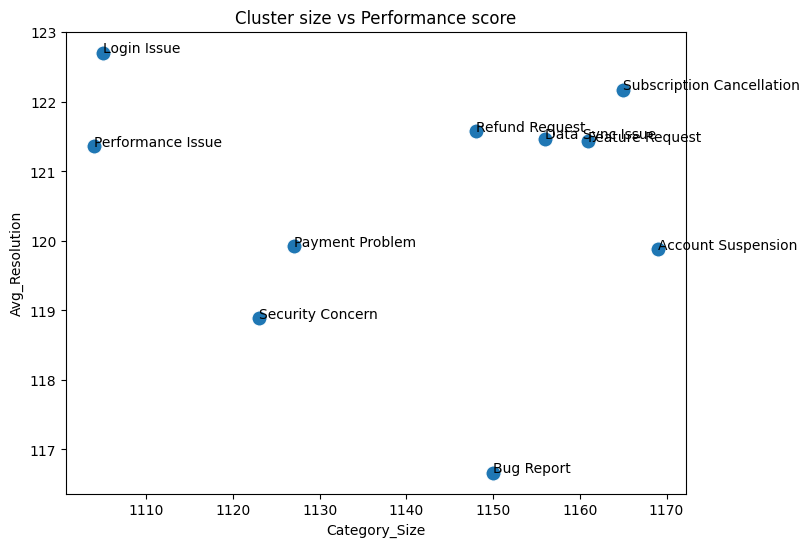

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
category_counts = df['category'].value_counts().reset_index()
category_counts.columns = ['category', 'Category_Size']
category_analysis = pd.merge(category_perf, category_counts, on='category')
category_analysis.rename(columns={'Resolution_Duration': 'Avg_Resolution'}, inplace=True)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=category_analysis,
    x='Category_Size',
    y='Avg_Resolution',
    s=120
)

for i in range(len(category_analysis)):
    plt.text(
        category_analysis['Category_Size'][i],
        category_analysis['Avg_Resolution'][i],
        category_analysis['category'][i]
    )

plt.title("Cluster size vs Performance score")

plt.show()

Performance metrics

In [ ]:
print("Average Resolution Duration")
print(df['Resolution_Duration'].mean())

print("\nPriority Distribution")
print(df['priority'].value_counts())

print("\nTop Categories")
print(df['category'].value_counts().head())

print("\nRegion Distribution")
print(df['region'].value_counts())

Average Resolution Duration
120.6039507363254

Priority Distribution
priority
Urgent    2915
Low       2900
Medium    2807
High      2786
Name: count, dtype: int64

Top Categories
category
Account Suspension           1169
Subscription Cancellation    1165
Feature Request              1161
Data Sync Issue              1156
Bug Report                   1150
Name: count, dtype: int64

Region Distribution
region
North America    1947
Africa           1924
South America    1917
Asia             1891
Oceania          1880
Europe           1849
Name: count, dtype: int64
